# News Data Collection — Overview

## Events & Data Sources Summary

This notebook collects news coverage data for major Internet infrastructure outage events, split into Pre-AI and Post-AI periods (using ChatGPT's launch in Nov 2022 as the dividing line).

### Pre-AI Events

| Event | Company | Date | NYT | Guardian | GDELT |
|---|---|---|---|---|---|
| Cloudflare outage | Cloudflare | 2019-07-02 | 1 article (Archive API) | 0 articles | 38 records (GKG, Jul 1–4) |
| Google global outage | Google | 2020-12-14 | 6 articles (Article Search API, Dec 12–20) | 5 articles (Content API, Dec 12–20) | — |
| Fastly CDN outage | Fastly | 2021-06-08 | 0 articles | 19 articles (Content API, Jun 6–20) | — |
| Facebook/Instagram/WhatsApp global outage | Meta/Facebook | 2021-10-04 | 15 direct + 85 related (Archive API, Oct 2021) | 139 articles (Content API, Oct 2021) | — |
| AWS US-EAST-1 outage | AWS | 2021-12-07 | 1 article (Article Search API, Dec 5–15) | 2 articles (Content API, Dec 5–15) | 329 records (GKG, Dec 7–10) |
| **Pre-AI Raw Total** | | | **108 articles** | **165 articles** | **367 records** |

### Post-AI Events

| Event | Company | Date | NYT | Guardian | GDELT |
|---|---|---|---|---|---|
| CrowdStrike global IT outage | CrowdStrike | 2024-07-19 | 40 articles (Article Search API, Jul 15–Sep 15) | 64 articles (Content API, Jul 15–Sep 15) | — |
| Google Cloud outage | Google | 2025-06-12 | 0 articles | 67 articles (Content API, Jun 10–20) | — |
| AWS outage | AWS | 2025-10-20 | 16 articles (Article Search API, Oct 18–Dec 1) | 35 articles (Content API, Oct 18–Dec 1) | — |
| Microsoft Azure outage | Microsoft | 2025-10-29 | 0 articles | 8 articles (Content API, Oct 25–Nov 10) | — |
| Cloudflare outage | Cloudflare | 2025-11-18 | 1 article (Archive API, window: Nov 17–21) | 2 articles (Content API) | 620 records (GKG, Nov 17–20) |
| **Post-AI Raw Total** | | | **57 articles** | **176 articles** | **620 records** |

### Overall Raw Totals

| | NYT | Guardian | Total |
|---|---|---|---|
| Pre-AI (5 events) | 108 | 165 | 273 |
| Post-AI (5 events) | 57 | 176 | 233 |
| **Total (10 events)** | **165** | **341** | **506** |

### Additional: Full Cloudflare timeline (all sources, 2009–2026)

| Source | Query | Articles |
|---|---|---|
| NYT Article Search API | `q="cloudflare"`, 2009-01-01 to 2026-02-02 | 10 articles |
| Guardian Content API | `q='cloudflare OR "cloud flare"'`, 2009-01-01 to 2026-02-02 | 9 articles |

### Data Collection Methods

| Source | Method | Type |
|---|---|---|
| New York Times | Archive API + Article Search API | API |
| The Guardian | Content Search API (`/search`) | API |
| GDELT GKG | Direct CSV download from data.gdeltproject.org, then local processing | Manual download + processing |
| Official Post-Mortems | web scraping/manual adding official reports (10 events) | Scraping + Manual adding |

### Notes

- **Analysis pipeline uses only NYT and Guardian data.** GDELT data was collected but not used in the final analysis due to noisy, non-mainstream sources.
- **API search windows vary across events** because each incident differs in duration, scale of impact, and length of media coverage. Wider windows (e.g., Jul 15–Sep 15 for CrowdStrike) were used for events with prolonged coverage, while narrower windows (e.g., Jun 6–20 for Fastly) were used for shorter-lived incidents. The goal in all cases is to capture as many relevant articles as possible while keeping noise manageable.
- NYT API returned 0 results for several events (Fastly 2021, Azure 2025, Google Cloud 2025). 
- Article counts above are raw numbers before relevance filtering. Many results are noise (unrelated articles matching broad queries). The cleaning pipeline filters articles using outage-related keywords.
- AWS 2021 event has very limited NYT/Guardian coverage (1 + 2 articles) plus GDELT data.
- Cloudflare 2025 is included but has very few articles (1 NYT, ~2 Guardian relevant).
- Post-mortem reports (postmortem_all.csv) are kept separate from news data.

# Official Post-Mortem / Incident Reports (Web Scraping)

- Author: Brittany An
- Purpose: Scrape official engineering post-mortem blog posts and updates from Cloudflare, Meta, and AWS as "technical ground truth" for each outage event.



**Pre-AI Events:**

- Cloudflare 2019-07-02

    - https://blog.cloudflare.com/details-of-the-cloudflare-outage-on-july-2-2019/


- Facebook 2021-10-04

    - https://engineering.fb.com/2021/10/04/networking-traffic/outage/ （short update)
    - https://engineering.fb.com/2021/10/05/networking-traffic/outage-details/ （more details）


- AWS 2021-12-07

    - https://aws.amazon.com/message/12721/


**Post-AI Event:**

- Cloudflare 2025-11-18

    - https://blog.cloudflare.com/18-november-2025-outage/

**Method:** `requests.get()` + `BeautifulSoup` to extract article body text.  
**Extract:** Title and body paragraphs (plain text). Images, code blocks, and navigation elements are skipped.  
**Output:** A single CSV (`postmortem_all.csv`) with one row per article.

## import packages and set user-agent

In [1]:
import requests                        
from bs4 import BeautifulSoup as bs 
import pandas as pd

header = { "User-Agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.183 Safari/537.36" } 

## Cloudflare 2019-07-02

In [2]:
cloudflare_2019 = "https://blog.cloudflare.com/details-of-the-cloudflare-outage-on-july-2-2019/"
response = requests.get(cloudflare_2019) # get the data

In [3]:
response = requests.get(cloudflare_2019, headers = header)
response

<Response [200]>

In [4]:
response_txt = response.text
soup = bs(response_txt, 'html.parser')
print(soup.prettify())

<!DOCTYPE html>
<script src="/_astro/index.astro_astro_type_script_index_0_lang.CoXd8L9s.js" type="module">
</script>
<html dir="ltr" lang="en-us">
 <head>
  <meta charset="utf-8"/>
  <script async="" data-document-language="true" data-domain-script="b1e05d49-f072-4bae-9116-bdb78af15448" src="https://ot.www.cloudflare.com/public/vendor/onetrust/scripttemplates/otSDKStub.js" type="text/javascript">
  </script>
  <script type="text/javascript">
   window.loadScript = (url, { charset = 'UTF-8', ...attributes } = {}, location = 'head') => {
      const existingScript = document.querySelector('script[src="' + url + '"]');
      if (existingScript) {
        return;
      }

      const script = document.createElement('script');
      script.src = url;
      script.type = 'text/javascript';

      script.async = true;
      script.charset = charset;

      if (attributes) {
        Object.entries(attributes).forEach(([key, value]) => {
          script.setAttribute(key, value);
        });
 

In [5]:
article = soup.find("article")
title_cf19 = article.find("h1").get_text(strip=True)

content = article.find("section", class_="post-full-content")

paragraphs = content.find_all(["p", "h2", "h3", "h4"]) # paragraph/headings
body_cf19 = " ".join(
    p.get_text(strip=True)     # extract clean text from each <p>/<h2>/<h3>/<h4>
    for p in paragraphs        # iterate over all matched tags
    if p.get_text(strip=True)) # skip empty tags

print(f"Title: {title_cf19}")
print(f"Body: {len(body_cf19):,} chars")

Title: Details of the Cloudflare outage on July 2, 2019
Body: 26,207 chars


## Facebook 2021-10-04

- https://engineering.fb.com/2021/10/04/networking-traffic/outage/
- https://engineering.fb.com/2021/10/05/networking-traffic/outage-details/

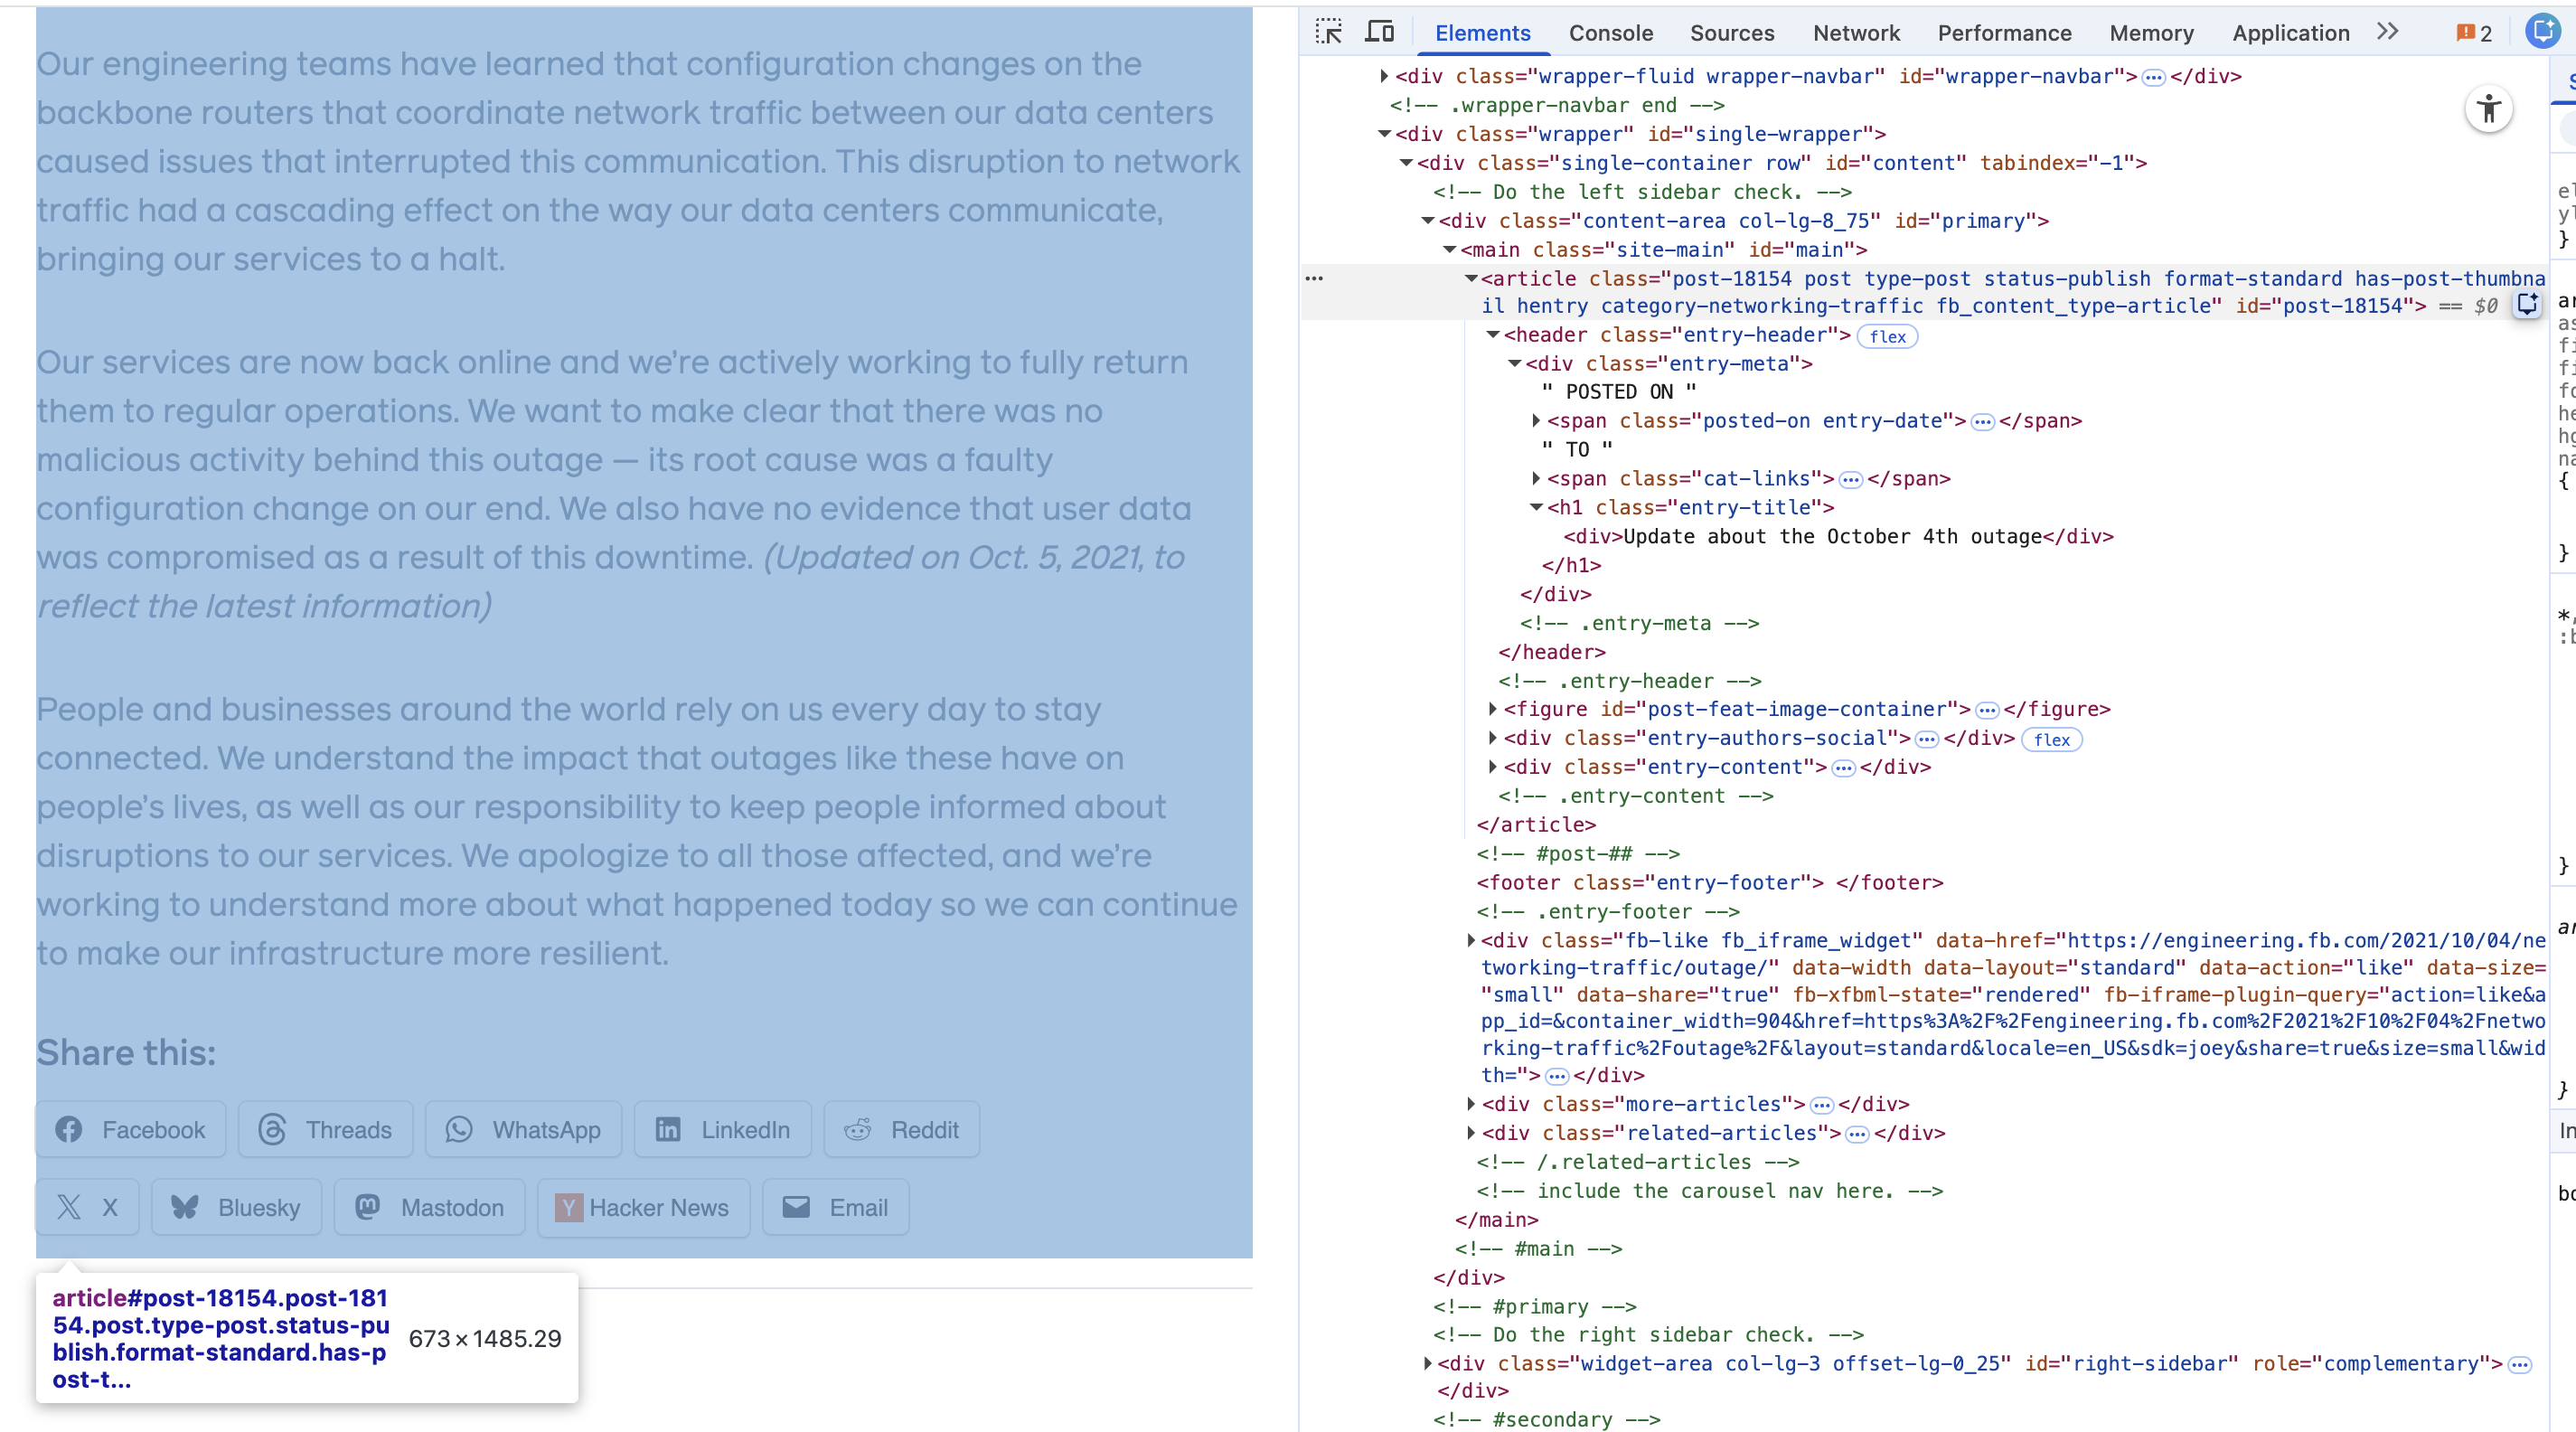

In [6]:
# Facebook 2021-10-04 (initial statement)
fb_url1 = "https://engineering.fb.com/2021/10/04/networking-traffic/outage/"
response = requests.get(fb_url1, headers=header)
soup = bs(response.text, 'html.parser')

article = soup.find("article")
title_fb1 = article.find("h1").get_text(strip=True)

content = article.find("div", class_="entry-content")
paragraphs = content.find_all(["p", "h2", "h3", "h4"])
body_fb1 = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

print(f"Title: {title_fb1}")
print(f"Body: {len(body_fb1):,} chars")

Title: Update about the October 4th outage
Body: 1,578 chars


In [7]:
# Facebook 2021-10-04 (detailed post-mortem)
fb_url2 = "https://engineering.fb.com/2021/10/05/networking-traffic/outage-details/"
response = requests.get(fb_url2, headers=header)
soup = bs(response.text, 'html.parser')

article = soup.find("article")
title_fb2 = article.find("h1").get_text(strip=True)

content = article.find("div", class_="entry-content")
paragraphs = content.find_all(["p", "h2", "h3", "h4"])
body_fb2 = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

print(f"Title: {title_fb2}")
print(f"Body: {len(body_fb2):,} chars")

Title: More details about the October 4 outage
Body: 6,301 chars


## AWS 2021-12-07

In [8]:
# AWS 2021-12-07
aws_url = "https://aws.amazon.com/message/12721/"
response = requests.get(aws_url, headers=header)
soup = bs(response.text, 'html.parser')

title_aws = soup.find("h1").get_text(strip=True)
content = soup.find("main") # use the main tag here

paragraphs = content.find_all(["p", "h2", "h3", "h4"])
body_aws = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

print(f"Title: {title_aws}")
print(f"Body: {len(body_aws):,} chars")

Title: Summary of the AWS Service Event in the Northern Virginia (US-EAST-1) Region
Body: 24,702 chars


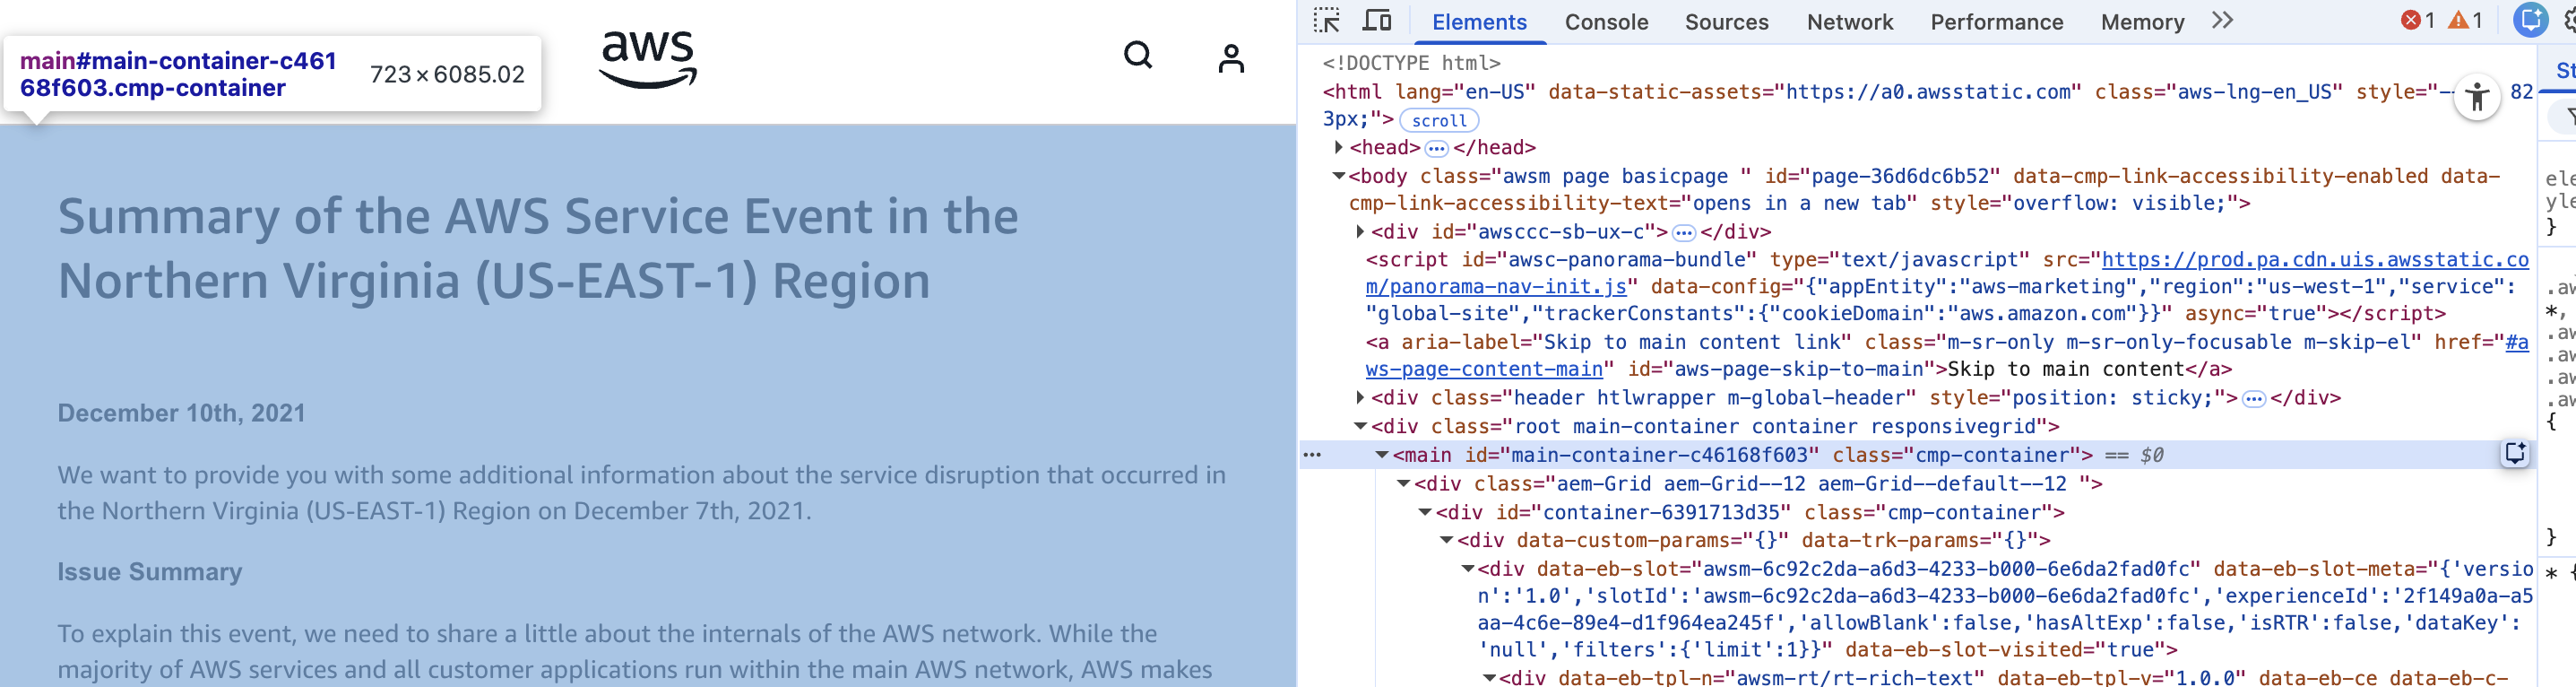

## Cloudflare 2025-11-18

In [9]:
# Cloudflare 2025-11-18
cloudflare_2025 = "https://blog.cloudflare.com/18-november-2025-outage/"
response = requests.get(cloudflare_2025, headers=header)
soup = bs(response.text, 'html.parser')

article = soup.find("article")
title_cf25 = article.find("h1").get_text(strip=True)

content = article.find("section", class_="post-full-content")
paragraphs = content.find_all(["p", "h2", "h3", "h4"])
body_cf25 = " ".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

print(f"Title: {title_cf25}")
print(f"Body: {len(body_cf25):,} chars")

Title: Cloudflare outage on November 18, 2025
Body: 17,961 chars


## Save as one CSV file

In [10]:
# Combine all as one DataFrame
df_all = pd.DataFrame([
    {"event": "cloudflare_2019", "event_date": "2019-07-02", "company": "Cloudflare",    "source_url": cloudflare_2019, "title": title_cf19, "body_text": body_cf19},
    {"event": "facebook_2021",   "event_date": "2021-10-04", "company": "Meta/Facebook", "source_url": fb_url1,         "title": title_fb1,  "body_text": body_fb1},
    {"event": "facebook_2021",   "event_date": "2021-10-04", "company": "Meta/Facebook", "source_url": fb_url2,         "title": title_fb2,  "body_text": body_fb2},
    {"event": "aws_2021",        "event_date": "2021-12-07", "company": "AWS",           "source_url": aws_url,         "title": title_aws,  "body_text": body_aws},
    {"event": "cloudflare_2025", "event_date": "2025-11-18", "company": "Cloudflare",    "source_url": cloudflare_2025, "title": title_cf25, "body_text": body_cf25},
])

df_all

,event,event_date,company,source_url,title,body_text
0,cloudflare_2019,2019-07-02,Cloudflare,https://blog.cloudflare.com/details-of-the-clo...,"Details of the Cloudflare outage on July 2, 2019","Almost nine years ago, Cloudflare was a tiny c..."
1,facebook_2021,2021-10-04,Meta/Facebook,https://engineering.fb.com/2021/10/04/networki...,Update about the October 4th outage,To all the people and businesses around the wo...
2,facebook_2021,2021-10-04,Meta/Facebook,https://engineering.fb.com/2021/10/05/networki...,More details about the October 4 outage,Now that our platforms are up and running as u...
3,aws_2021,2021-12-07,AWS,https://aws.amazon.com/message/12721/,Summary of the AWS Service Event in the Northe...,"December 10th, 2021 We want to provide you wit..."
4,cloudflare_2025,2025-11-18,Cloudflare,https://blog.cloudflare.com/18-november-2025-o...,"Cloudflare outage on November 18, 2025",On 18 November 2025 at 11:20 UTC (all times in...


In [11]:
# Save to CSV
df_all.to_csv("postmortem_all.csv", index=False)
print(f"Saved {len(df_all)} rows to postmortem_all.csv")

Saved 5 rows to postmortem_all.csv


## Note: for later added events we simply copied and pasted the official reports manually into our postmortem_all.csv file


- CrowdStrike 2024: https://www.crowdstrike.com/en-us/blog/falcon-content-update-preliminary-post-incident-report/
- Fastly 2021: https://www.fastly.com/blog/summary-of-june-8-outage
- Google 2020: https://status.cloud.google.com/incident/zall/20013 (Google's official incident report)
- Google Cloud 2025: https://status.cloud.google.com/incidents/ow5i3PPK96RduMcb1SsW
- AWS 2025: https://aws.amazon.com/message/101925/ (the DynamoDB Oct 19, 2025 entry)
- Azure 2025: https://azure.status.microsoft/en-us/status/history/?trackingId=YKYN-BWZ

In [11]:
# full postmortem_all.csv check
import os
import pandas as pd

BASE_path = "/Users/brittanyan/Desktop/final-project-error-502/data/post_AI"
df = pd.read_csv(f"{BASE_path}/postmortem_all.csv")
df.columns

Index(['event', 'event_date', 'company', 'source_url', 'title', 'body_text'], dtype='object')

In [15]:
df

,event,event_date,company,source_url,title,body_text
0,cloudflare_2019,2019-07-02,Cloudflare,https://blog.cloudflare.com/details-of-the-clo...,"Details of the Cloudflare outage on July 2, 2019","Almost nine years ago, Cloudflare was a tiny c..."
1,google_2020,2020-12-14,Google,https://status.cloud.google.com/incident/zall/...,Google Cloud Infrastructure Components Inciden...,"ISSUE SUMMARY On Monday 14 December, 2020, for..."
2,fastly_2021,2021-06-08,Fastly,https://www.fastly.com/blog/summary-of-june-8-...,Summary of June 8 outage,We experienced a global outage due to an undis...
3,facebook_2021,2021-10-04,Meta/Facebook,https://engineering.fb.com/2021/10/04/networki...,Update about the October 4th outage,To all the people and businesses around the wo...
4,facebook_2021,2021-10-04,Meta/Facebook,https://engineering.fb.com/2021/10/05/networki...,More details about the October 4 outage,Now that our platforms are up and running as u...
5,aws_2021,2021-12-07,AWS,https://aws.amazon.com/message/12721/,Summary of the AWS Service Event in the Northe...,"December 10th, 2021 We want to provide you wit..."
6,crowdstrike_2024,2024-07-19,CrowdStrike,https://www.crowdstrike.com/en-us/blog/falcon-...,Falcon Content Update Preliminary Post Inciden...,"On Friday, July 19, 2024 at 04:09 UTC, as part..."
7,google_cloud_2025,2025-06-12,Google,https://status.cloud.google.com/incidents/ow5i...,Multiple GCP products are experiencing Service...,"Google Cloud, Google Workspace and Google Secu..."
8,aws_2025,2025-10-20,AWS,https://aws.amazon.com/message/101925/,Summary of the Amazon DynamoDB Service Disrupt...,We want to provide you with information about ...
9,azure_2025,2025-10-29,Microsoft,https://azure.status.microsoft/en-us/status/hi...,Azure Front Door and Azure CDN - Connectivity ...,Between 15:41 UTC on 29 October and 00:05 UTC ...


# New York Times API

- Author: Brittany An
- Purpose: Query the NYT Archive API for a given month and extract articles mentioning "Cloudflare" within an event window.
- AI usage: Used AI for debugging details such as Timestamp usage and adding robust error handling. Also used AI to understand the NYT API structure and response fields



- Note: Very limited news data from NYT regarding the specific Cloudflare event, but will still include it in our dataset for now

- API reference: https://developer.nytimes.com/apis
- github code example:
  - https://github.com/nytimes/public_api_specs/blob/master/archive_api/archive_api.md

### NYT Archive API — Reference & Usage Notes

**Official docs:** https://developer.nytimes.com/docs/archive-product/1/overview  
**API specs (GitHub):** https://github.com/nytimes/public_api_specs/blob/master/archive_api/archive_api.md

**Endpoint:**
```
GET https://api.nytimes.com/svc/archive/v1/{year}/{month}.json?api-key={YOUR_KEY}
```
- The only path parameters are `year` (int) and `month` (int, 1–12).
- Authentication is via the `api-key` query parameter.
- The response is a single large JSON blob (can be ~20 MB) containing **all** articles published by the NYT in that month.

**Response structure:**
```json
{
  "response": {
    "meta": { "hits": 612 },
    "docs": [ { ... }, { ... }, ... ]
  }
}
```
Each element in `docs` is an article metadata dict. The Archive API shares the **same response schema** as the Article Search API (documented at https://developer.nytimes.com/docs/articlesearch-product/1/overview). Key fields we extract:

| Field | Type | Description |
|---|---|---|
| `headline` | dict | Contains sub-key `main` (the display headline) and optionally `kicker`, `print_headline`, etc. |
| `snippet` | str | A short summary/excerpt of the article (often same as `abstract`). |
| `abstract` | str | Brief description of the article content. |
| `lead_paragraph` | str | The opening paragraph of the article. |
| `web_url` | str | Full URL to the article on nytimes.com. |
| `pub_date` | str | ISO-8601 publication timestamp, e.g. `"2019-07-02T15:30:00+0000"`. |
| `source` | str | Typically `"The New York Times"`. |
| `document_type` | str | e.g. `"article"`, `"multimedia"`. |
| `type_of_material` | str | e.g. `"News"`, `"Blog"`, `"Op-Ed"`. |
| `section_name` | str | e.g. `"Technology"`, `"Business"`. |
| `keywords` | list[dict] | Each has `name`, `value`, `rank`. |
| `byline` | dict | Author info; sub-key `original` has the byline string. |
| `word_count` | int | Word count of the article. |
| `_id` | str | Unique article identifier. |

**Important notes:**
- The API returns **metadata only** — full article text is not available through the API.
- `headline` is a nested dict, so we access the main headline via `d["headline"]["main"]`.
- Some fields may be `None` or missing for older articles, so defensive access (e.g. `.get()`) is necessary.
- Rate limit: 10 requests/minute, 4,000 requests/day.


Note:
- In the NYT API response, headline is not a plain string — it's a nested dict containing multiple sub-fields:

In [ ]:
# Example:
# "headline": {
#     "main": "Virginia Attorney General Backs Off Ballot Proposal",
#     "kicker": "The Caucus",
#     "content_kicker": null,
#     "print_headline": "Bypassing Congress to Appoint Ally...",
#     "name": null,
#     "seo": null,
#     "sub": null
# }

- main — The primary display headline (the one shown on the website). This is what we extract.
- kicker — A small label above the headline indicating the column or series (e.g. "The Caucus", "Breaking News").
- print_headline — The headline used in the print edition, which may differ from the web version.
content_kicker, name, seo, sub — Other variants, usually null.

- That's why the code uses d["headline"]["main"] rather than d["headline"] directly — the latter would return the entire dict, not the headline string.
- And the defensive pattern (d.get("headline") or {}).get("main", "") guards against cases where headline itself is None (possible for very old articles), preventing a TypeError.

## Year 2019

In [12]:
NYT_API_KEY = "CMGreORSsTHjuDp7M757hg7Jc3xXF2N1S97SrGk1Sl72Us6G" 

In [13]:
import os
import json
import requests
import pandas as pd

In [14]:
# Fetch one month of NYT Archive docs
def fetch_archive_month(year, month):
    """
    Send a request to the NYT Archive API for a given year/month,
    and return the list of article metadata objects ("docs")
    """
    url = f"https://api.nytimes.com/svc/archive/v1/{year}/{month}.json"
    r = requests.get(url, params={"api-key": NYT_API_KEY}, timeout=120)

    # Helpful error messages (common issues: 401 unauthorized, 429 rate limit)
    if r.status_code == 401:
        raise RuntimeError("NYT API returned 401 Unauthorized. Check NYT_API_KEY.")
    if r.status_code == 429:
        raise RuntimeError("NYT API returned 429 Too Many Requests. Try waiting and rerunning.")

    r.raise_for_status()
    # avoid None.get("docs") AttributeError
    return (r.json().get("response") or {}).get("docs") or []

In [15]:
# Extract Cloudflare mentions within an event window
def extract_cloudflare_articles(docs: list, start_utc: pd.Timestamp, end_utc: pd.Timestamp):
    """
    Filter month docs by:
    (i) publication time within start_utc and end_utc window
    (ii) "cloudflare" or "cloud flare" mentioned in headline/snippet/lead/url
    Returns a DataFrame.
    """
    rows = []

    for d in docs:
        pub = pd.to_datetime(d.get("pub_date"), utc=True, errors="coerce")
        # make sure publication_date can compare and is within the selected window
        if pd.isna(pub) or not (start_utc <= pub < end_utc):
            continue

        headline = (d.get("headline") or {}).get("main", "") or ""
        snippet  = d.get("snippet", "") or d.get("abstract", "") or ""
        lead     = d.get("lead_paragraph", "") or ""
        url      = d.get("web_url", "") or ""

        # lowercase for case-insensitive search
        text = f"{headline} {snippet} {lead} {url}".lower()

        if ("cloudflare" not in text) and ("cloud flare" not in text):
            continue

        rows.append({
            "pub_datetime_utc": pub,
            "headline": headline,
            "snippet_or_abstract": snippet,
            "lead_paragraph": lead,
            "web_url": url,
            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "",
        })

    df = pd.DataFrame(rows).sort_values("pub_datetime_utc").reset_index(drop=True)
    return df

In [16]:
# Event window selection
start_utc = pd.Timestamp("2019-07-01T00:00:00Z")
end_utc   = pd.Timestamp("2019-07-05T00:00:00Z")

# Could extend as needed
# event = pd.Timestamp("2019-07-02T00:00:00Z")
# start_utc = event - pd.Timedelta(days=14)
# end_utc   = event + pd.Timedelta(days=15)


docs = fetch_archive_month(2019, 7)
df = extract_cloudflare_articles(docs, start_utc, end_utc)
df.to_csv("nyt_cloudflare_2019-07-02.csv", index=False)

print("saved:", len(df), "rows")

saved: 1 rows


In [17]:
df

,pub_datetime_utc,headline,snippet_or_abstract,lead_paragraph,web_url,section,byline
0,2019-07-03 00:42:03+00:00,"A Failure Here, Damaged Fiber There and a Day ...",Cloudflare and Google dealt with issues that a...,"When a website won’t load, many internet users...",https://www.nytimes.com/2019/07/02/business/cl...,Business Day,By David Yaffe-Bellany


## Year 2025 

In [18]:
# Event window selection for year 2025
start_utc = pd.Timestamp("2025-11-17T00:00:00Z")
end_utc   = pd.Timestamp("2025-11-21T00:00:00Z")

docs = fetch_archive_month(2025, 11)
df = extract_cloudflare_articles(docs, start_utc, end_utc)
df.to_csv("nyt_cloudflare_2025-11-18.csv", index=False)

print("saved:", len(df), "rows")

saved: 1 rows


In [19]:
df

,pub_datetime_utc,headline,snippet_or_abstract,lead_paragraph,web_url,section,byline
0,2025-11-18 12:16:11+00:00,Cloudflare Says It Has Resolved Outage That Di...,"Services from Cloudflare, a software company, ...",,https://www.nytimes.com/2025/11/18/business/cl...,Business,By Victor Mather


# New York Times API2_FULL

- Author : Brittany An
- Puporse: Query the NYT article search API using keyword filter for all 'Cloudflare' relevant news used for later event filter starting from 2009(company founded date)
- AI used for API understanding, debugging, and robustness checks such as avoding duplicates

- Note: need to cut windows due to pagination limits just in case of over result limites (not a issue here, but still processed by year)

API reference: https://developer.nytimes.com/docs/articlesearch-product/1/overview

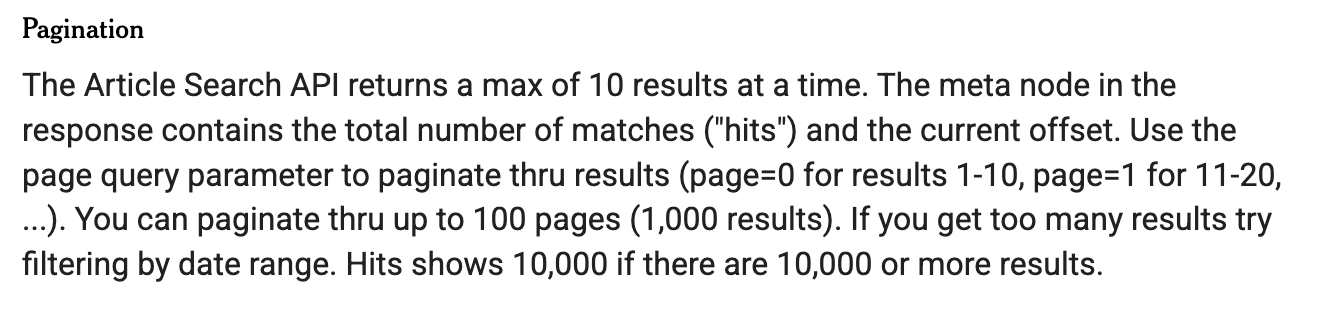

### NYT Article Search API — Reference & Usage Notes

**Official docs:** https://developer.nytimes.com/docs/articlesearch-product/1/overview  
**API specs (GitHub):** https://github.com/nytimes/public_api_specs/blob/master/article_search/article_search_v2.md

**Endpoint:**
```
GET https://api.nytimes.com/svc/search/v2/articlesearch.json
```

**Query parameters:**

| Parameter | Format | Description |
|---|---|---|
| `q` | str | Full-text search query (searches body, headline, byline). Case-insensitive. |
| `api-key` | str | Your API key. |
| `begin_date` | `YYYYMMDD` | Restrict to articles on or after this date. |
| `end_date` | `YYYYMMDD` | Restrict to articles on or before this date. |
| `fq` | Lucene syntax | Filter query, e.g. `type_of_material:("News")`. |
| `page` | int (0–100) | Page number; each page returns 10 results. |
| `sort` | str | `"newest"`, `"oldest"`, or `"relevance"` (default). |
| `fl` | comma-separated | Fields to return (default includes `web_url`, `snippet`, `headline`, `pub_date`, etc.). |

**Response structure:** Same `docs` schema as the Archive API (see table above).  
**Pagination:** Max 10 results per page, max 100 pages (1,000 results total per query). To retrieve more, narrow the date range.  
**Rate limit:** 10 requests/minute, 4,000 requests/day — use `time.sleep()` between pages.


In [ ]:
# NYT_API_KEY = "Fmh19bhWAPW7ieQTzh8k2P0OLPj3qxLMGfgRdVCbcGAf47T6"

In [84]:
import os
import time
import math
import requests
import pandas as pd
from datetime import datetime

In [ ]:
# fetch by year to avoid pagination/results limits
# filter_query used to restrict article types, such as news articles

def fetch_year(q, year, filter_query=None):
    """
    Fetch NYT news for a given calendar year

    Inputs:
        q(str): Full-text search query ("cloudflare")
        year(int): Calendar year to fetch
        filter_query(str or None): Field-based filter query using Lucene syntax to restrict
        results by structured metadata fields (e.g. 'typeOfMaterials:News')

    Returns a list of NYT "docs" objects(raw JSON dicts) for one year.
    Note each element is one article metadata record.
    """
    begin = f"{year}0101"
    end   = f"{year}1231"
    if year == END_YEAR:
        end = END_CUTOFF # cut off only for 2026

    docs_all = []
    page = 0

    # pagination limit 100
    while page < 100:
        params = {
            "api-key": NYT_API_KEY,
            "q": q,
            "begin_date": begin,
            "end_date": end,
            "page": page,
            "sort": "oldest",
        }
        if filter_query: # only when filter_query is not None
            params["fq"] = filter_query

        r = requests.get(base_url, params=params, timeout=60)
        if r.status_code == 429:
            # # basic rate limit handling
            time.sleep(2)
            continue

        r.raise_for_status()

        data = r.json()
        docs = (data.get("response") or {}).get("docs") or []

        if not docs: # no docs returned for this page
            # stop paging(reached end or no matches)
            break

        docs_all.extend(docs)
        page += 1
        # only move to the next page when success to avoid skipping pages due to 429
        time.sleep(0.3)

    return docs_all

In [ ]:
def to_df(docs):
    """
    Convert a list of NYT news "docs"(raw JSON dicts) into a pandas DataFrame

    Input:
        docs: List of dict. Each dict contains metadata for one article

    Returns: A dataframe each row per article with selected fields
    """
    rows = []
    for d in docs:
        rows.append({
            "_id": d.get("_id", ""), # unique for each article
            "pub_date": d.get("pub_date", ""),
            "headline": (d.get("headline") or {}).get("main", "") or "",
            "web_url": d.get("web_url", "") or "",
            "snippet": d.get("snippet", "") or d.get("abstract", "") or "",
            # in case no snippet, keep abstract

            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "", # author info
            "type_of_material": d.get("type_of_material", "") or "",
            "source": d.get("source", "") or "",
        })

    df = pd.DataFrame(rows)

    if "pub_date" in df.columns:
        # in case no news for the year, rows will be empty
        df["pub_date"] = pd.to_datetime(df["pub_date"], utc=True, errors="coerce")

    return df

In [49]:
base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

In [ ]:
# fix end data cutoff to 2026-02-02
START_YEAR = 2009
END_YEAR   = 2026
END_CUTOFF = "20260202"
# FILTER_QUERY = 'typeOfMaterials:News'
q = 'cloudflare'  # case-insensitive

In [ ]:
all_docs = []

for y in range(START_YEAR, END_YEAR + 1):
    docs_y = fetch_year(q, y, filter_query=FILTER_QUERY)
    all_docs.extend(docs_y)
    print("year", y, "docs", len(docs_y))

df = to_df(all_docs)
df = df.sort_values("pub_date").drop_duplicates("_id").reset_index(drop=True)
# avoid duplicates, drop articles with same unique id

out_file = f"nyt_cloudflare_{START_YEAR}0101_{END_CUTOFF}.csv"
df.to_csv(out_file, index=False)
print("saved:", len(df), "rows in ", out_file)

year 2009 docs 5
year 2010 docs 0
year 2011 docs 0
year 2012 docs 3
year 2013 docs 10
year 2014 docs 10
year 2015 docs 8
year 2016 docs 2
year 2017 docs 8
year 2018 docs 3
year 2019 docs 13
year 2020 docs 5
year 2021 docs 6
year 2022 docs 3
year 2023 docs 3
year 2024 docs 7
year 2025 docs 8
year 2026 docs 28
saved: 122 rows in  nyt_cloudflare_20090101_20260202.csv


## basic processing

- initial processing to filter actual Cloudflare related news

In [95]:
import os
import pandas as pd
base_path = "/Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project"
raw_file_path = os.path.join(base_path,"nyt_cloudflare_20090101_20260202.csv")
df_raw = pd.read_csv(raw_file_path)

In [97]:
df_raw.head()

,_id,pub_date,headline,web_url,snippet,section,byline,type_of_material,source
0,nyt://article/26a70ca4-d10f-57d6-818d-cf55592b...,2009-08-13 17:19:05+00:00,TD2 Barely Holding On,https://topics.blogs.nytimes.com/2009/08/13/td...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
1,nyt://article/652261c8-c8a5-55cb-a6fc-64101722...,2009-08-14 20:21:21+00:00,"TD2 Dissipates, Easterly Wave Getting Organized",https://topics.blogs.nytimes.com/2009/08/14/td...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
2,nyt://article/4e732e0e-7d06-5913-b72a-83c93a73...,2009-08-17 21:13:04+00:00,"Ana, Bill, and Claudette Made for a Full Weekend",https://topics.blogs.nytimes.com/2009/08/17/an...,.,Times Topics,By Brian McNoldy,News,The New York Times
3,nyt://article/73adede5-856d-591a-8d03-9054d95f...,2009-08-19 19:14:00+00:00,Bill Strengthens to a Category 4 Hurricane,https://topics.blogs.nytimes.com/2009/08/19/bi...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
4,nyt://article/b2fec01f-d4b3-51ef-a944-2e49e62c...,2009-08-21 21:10:50+00:00,Bill Heads Northwest Between Bermuda and U.S.,https://topics.blogs.nytimes.com/2009/08/21/bi...,.,Times Topics,By Brian D. McNoldy,News,The New York Times


In [99]:
df_raw.columns

Index(['_id', 'pub_date', 'headline', 'web_url', 'snippet', 'section',
       'byline', 'type_of_material', 'source'],
      dtype='object')

In [101]:
df_raw.type_of_material.value_counts()

type_of_material
News    122
Name: count, dtype: int64

In [103]:
# build a text field from columns for rough filtering
text = (
    df[["headline", "snippet", "web_url"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

# keep only rows where the word "cloudflare" appears (not just "cloud")
mask = text.str.contains(r"\bcloud\s*flare\b", regex=True)

df2 = df.loc[mask].copy()
df2["pub_date"] = pd.to_datetime(df2["pub_date"], utc=True, errors="coerce")

out_file2 = f"NEW_nyt_cloudflare_{START_YEAR}0101_{END_CUTOFF}.csv"
df2 = df2.sort_values("pub_date").drop_duplicates("_id").reset_index(drop=True)
df2.to_csv(out_file2, index=False)

print("raw file:", len(df), "rows")
print("new file:", len(df2), "rows", out_file2)

raw file: 122 rows
new file: 10 rows NEW_nyt_cloudflare_20090101_20260202.csv


In [105]:
new_path = os.path.join(base_path,out_file2)

In [107]:
df_new = pd.read_csv(new_path)
df_new

,_id,pub_date,headline,web_url,snippet,section,byline,type_of_material,source
0,nyt://article/1a2bf51d-ca3a-50a2-b17a-0fc63111...,2012-02-17 17:54:32+00:00,Preparing for DDoS Attacks or Just Groundhog Day,https://bits.blogs.nytimes.com/2012/02/17/prep...,A number of companies help Web sites fight bas...,Technology,By Nicole Perlroth,News,The New York Times
1,nyt://article/cb404a07-5753-5f28-83a0-d4f25989...,2015-09-14 00:57:10+00:00,Baidu and CloudFlare Boost Users Over China’s ...,https://www.nytimes.com/2015/09/14/business/pa...,"The Chinese search giant Baidu and CloudFlare,...",Technology,By Paul Mozur,News,The New York Times
2,nyt://article/32e94921-1ba6-5f11-81b1-28ecae17...,2017-08-11 11:00:15+00:00,Matthew Prince of Cloudflare on the Dangers of...,https://www.nytimes.com/2017/08/11/business/co...,The chief executive of a cybersecurity firm sa...,Business,By Adam Bryant,News,The New York Times
3,nyt://article/ddcc81da-d52c-57cc-a5a2-2e2c549c...,2019-07-03 00:42:03+00:00,"A Failure Here, Damaged Fiber There and a Day ...",https://www.nytimes.com/2019/07/02/business/cl...,Cloudflare and Google dealt with issues that a...,Business,By David Yaffe-Bellany,News,The New York Times
4,nyt://article/049ea2fb-eaec-5b32-8313-6dcea654...,2019-08-04 18:01:29+00:00,"‘Shut the Site Down,’ Says the Creator of 8cha...",https://www.nytimes.com/2019/08/04/technology/...,The site is a venue for extremists to test out...,Technology,By Kevin Roose,News,The New York Times
5,nyt://article/99fc864c-e158-5670-9736-2ea7641a...,2019-08-05 14:24:13+00:00,Why Banning 8chan Was So Hard for Cloudflare: ...,https://www.nytimes.com/2019/08/05/technology/...,"8chan, the anonymous message board used by the...",Technology,By Kevin Roose,News,The New York Times
6,nyt://article/6094fa8d-1e99-5f52-b122-115bfb5a...,2024-04-09 14:42:25+00:00,Internet Traffic Dipped as Viewers Took in the...,https://www.nytimes.com/2024/04/09/business/in...,Internet traffic dropped by 40 percent or more...,Business,By Jenny Gross,News,The New York Times
7,nyt://article/e687c4db-d296-5f9a-96e9-a4469171...,2025-07-01 10:00:13+00:00,Cloudflare Introduces Default Blocking of A.I....,https://www.nytimes.com/2025/07/01/technology/...,The tech company’s customers can automatically...,Technology,By Natallie Rocha,News,The New York Times
8,nyt://article/5433efe5-6c47-5f84-b080-88a9806a...,2025-08-01 11:00:09+00:00,Age-Gating the Internet + Cloudflare Takes On ...,https://www.nytimes.com/2025/08/01/podcasts/ha...,"“Frankly, if they’re going to behave like hack...",Podcasts,"By Kevin Roose, Casey Newton, Rachel Cohn, Whi...",News,The New York Times
9,nyt://article/627eb1f3-c42e-51b6-8f88-8fdf9795...,2025-11-18 12:16:11+00:00,Cloudflare Says It Has Resolved Outage That Di...,https://www.nytimes.com/2025/11/18/business/cl...,"Services from Cloudflare, a software company, ...",Business,By Victor Mather,News,The New York Times


# NYT API_Extra Data

- Try gather extra event data

In [4]:
# NYT_API_KEY = "Fmh19bhWAPW7ieQTzh8k2P0OLPj3qxLMGfgRdVCbcGAf47T6"

In [17]:
# import os
# import time
# import math
# import requests
# from datetime import datetime

# import re
# import pandas as pd
# from typing import List, Optional

In [23]:
# # Fetch one month of NYT Archive docs
# def fetch_archive_month(year, month):
#     """
#     Send a request to the NYT Archive API for a given year/month,
#     and return the list of article metadata objects ("docs")
#     """
#     url = f"https://api.nytimes.com/svc/archive/v1/{year}/{month}.json"
#     r = requests.get(url, params={"api-key": NYT_API_KEY}, timeout=120)

#     # Helpful error messages (common issues: 401 unauthorized, 429 rate limit)
#     if r.status_code == 401:
#         raise RuntimeError("NYT API returned 401 Unauthorized. Check NYT_API_KEY.")
#     if r.status_code == 429:
#         raise RuntimeError("NYT API returned 429 Too Many Requests. Try waiting and rerunning.")

#     r.raise_for_status()
#     # avoid None.get("docs") AttributeError
#     return (r.json().get("response") or {}).get("docs") or []

In [51]:
# def extract_event_articles(
#     docs: List,
#     start_utc: pd.Timestamp,
#     end_utc: pd.Timestamp,
#     must_any: List[str],
#     should_any: Optional[List[str]] = None,
#     min_should_hits: int = 0,   # 1 = must hit one should word
# ):
#     rows = []
#     should_any = should_any or []

#     # avoid case issues
#     must_patterns   = [re.compile(re.escape(k), re.IGNORECASE) for k in must_any]
#     should_patterns = [re.compile(re.escape(k), re.IGNORECASE) for k in should_any]

#     for d in docs:
#         pub = pd.to_datetime(d.get("pub_date"), utc=True, errors="coerce")
#         if pd.isna(pub) or not (start_utc <= pub < end_utc):
#             continue

#         headline = (d.get("headline") or {}).get("main", "") or ""
#         snippet  = d.get("snippet", "") or d.get("abstract", "") or ""
#         lead     = d.get("lead_paragraph", "") or ""
#         url      = d.get("web_url", "") or ""
#         text = f"{headline} {snippet} {lead} {url}".lower()

#         # must include at least one must_patterns word
#         if not any(p.search(text) for p in must_patterns):
#             continue

#         # optional word hits
#         should_hits = sum(1 for p in should_patterns if p.search(text))
#         if should_hits < min_should_hits:
#             continue

#         rows.append({
#             "pub_datetime_utc": pub,
#             "headline": headline,
#             "snippet_or_abstract": snippet,
#             "lead_paragraph": lead,
#             "web_url": url,
#             "section": d.get("section_name", "") or "",
#             "byline": (d.get("byline") or {}).get("original", "") or "",
#             "should_hits": should_hits,  
#         })

#     df = pd.DataFrame(rows)
#     if len(df) == 0:
#         return df

#     return df.sort_values(["should_hits", "pub_datetime_utc"], ascending=[False, True]).reset_index(drop=True)


### 2017 S3 outage

In [19]:
# docs_feb = fetch_archive_month(2017, 2)
# docs_mar = fetch_archive_month(2017, 3)
# docs = docs_feb + docs_mar

# start_utc = pd.Timestamp("2017-02-28T00:00:00Z")
# end_utc   = pd.Timestamp("2017-03-15T00:00:00Z")


# in_window = 0
# missing_pub = 0
# for d in docs:
#     pub = pd.to_datetime(d.get("pub_date"), utc=True, errors="coerce")
#     if pd.isna(pub):
#         missing_pub += 1
#         continue
#     if start_utc <= pub < end_utc:
#         in_window += 1

# print("docs total:", len(docs))
# print("missing pub_date:", missing_pub)
# print("docs in window:", in_window)

# must_any = ["Amazon s3", "s3 outage","AWS", "aws s3", 
#             "simple storage service", "amazon web services","Amazon"]
# should_any = ["error","miscue","s3","maintenance", "down", "disruption", "interruption","storage",
#               "typo", "human error", "engineer", "command", "debug", "us-east-1"]


# df = extract_event_articles(docs, start_utc, end_utc, must_any, should_any, min_should_hits=0)
# df.to_csv("nyt_aws_s3_outage_2017-02-28.csv", index=False)
# print("saved:", len(df))

### 2016 Dyn DNS DDoS

In [15]:
# docs_oct = fetch_archive_month(2016, 10)
# docs_nov = fetch_archive_month(2016, 11)
# docs = docs_oct + docs_nov

# start_utc = pd.Timestamp("2016-10-20T00:00:00Z")
# end_utc   = pd.Timestamp("2016-11-30T00:00:00Z")

# must_any = ["dyn", "dyn dns"]
# should_any = ["ddos", "botnet", "mirai", "dns attack", "distributed denial",
#               "twitter", "netflix", "reddit", "cnn"]

# df = extract_event_articles(docs, start_utc, end_utc, must_any, should_any, min_should_hits=1)
# df.to_csv("nyt_dyn_ddos_2016-10-21.csv", index=False)
# print("saved:", len(df))


### 2021 Meta/Facebook BGP outage

In [17]:
# docs_oct = fetch_archive_month(2021, 10)
# docs_nov = fetch_archive_month(2021, 11)
# docs = docs_oct + docs_nov

# start_utc = pd.Timestamp("2021-10-03T00:00:00Z")
# end_utc   = pd.Timestamp("2021-11-10T00:00:00Z")

# must_any = ["facebook outage", "instagram outage", "whatsapp outage", "meta outage"]
# should_any = ["bgp", "routing", "route", "dns", "configuration", "misconfiguration", "worldwide", "global"]

# df = extract_event_articles(docs, start_utc, end_utc, must_any, should_any, min_should_hits=1)
# df.to_csv("nyt_meta_bgp_outage_2021-10-04.csv", index=False)
# print("saved:", len(df))

# The Guardian API

- Author: Brittany An
- Purpose: Query the Guardian Open Platform API for "Cloudflare" within a specified date range, then filter results to keep only relevant outage-related articles (remove briefing/liveblog noise).
- AI usage: ChatGPT was used to debug noisy news returns and refine filtering rules (e.g., exclude non-article types like liveblog/briefing) and generating outage_terms.Also used to help understand the Guardian API structure, query parameters, and response fields (see API notes below).

Note: Very limited news data from The Guardian as well regarding the specific Cloudflare event, but will still include it in our dataset for now

### Guardian Content Search API — Reference & Usage Notes

**Official docs:** https://open-platform.theguardian.com/documentation/  
**Content search docs:** https://open-platform.theguardian.com/documentation/search

**Endpoint:**
```
GET https://content.guardianapis.com/search
```

**Query parameters used in this project:**

| Parameter | Format | Description |
|---|---|---|
| `api-key` | str | Your Guardian API key (free developer tier available). |
| `q` | str | Free-text search query. Supports `AND`, `OR`, `NOT` operators and exact phrases in double quotes, e.g. `'cloudflare OR "cloud flare"'`. |
| `from-date` | `YYYY-MM-DD` | Return content published on or after this date. |
| `to-date` | `YYYY-MM-DD` | Return content published on or before this date. |
| `use-date` | str | Which date to filter on: `"published"` (default) or `"last-modified"`. |
| `order-by` | str | `"newest"`, `"oldest"`, or `"relevance"`. |
| `page-size` | int | Number of results per page (max **200**). |
| `page` | int | Page number for pagination (starts at 1). |
| `show-fields` | comma-separated | Extra fields to include in each result, e.g. `"trailText,bodyText"`. By default only core fields are returned; additional fields must be explicitly requested via this parameter. |

**Response structure:**
```json
{
  "response": {
    "status": "ok",
    "total": 310,
    "pages": 2,
    "currentPage": 1,
    "pageSize": 200,
    "results": [ { ... }, { ... }, ... ]
  }
}
```

Each element in `results` is a content item dict. Key fields:

| Field | Location | Description |
|---|---|---|
| `id` | top-level | Content path, e.g. `"technology/2019/jul/02/cloudflare-outage"`. |
| `type` | top-level | Content type: `"article"`, `"liveblog"`, `"interactive"`, etc. We filter to keep only `"article"`. |
| `webTitle` | top-level | The display headline of the content. (**Note:** unlike the NYT API where `headline` is a nested dict, Guardian's title is a flat string directly accessible via `item["webTitle"]`.) |
| `webUrl` | top-level | Full URL on theguardian.com. |
| `webPublicationDate` | top-level | ISO-8601 timestamp, e.g. `"2019-07-02T14:30:00Z"`. |
| `sectionName` | top-level | Section label, e.g. `"Technology"`. |
| `sectionId` | top-level | Section slug, e.g. `"technology"`. |
| `fields.trailText` | nested under `fields` | Short summary/standfirst (only returned if requested via `show-fields`). |
| `fields.bodyText` | nested under `fields` | Full article body as plain text (only returned if requested via `show-fields`). |

**Important notes:**
- Unlike the NYT API, the Guardian API **can** return full article text via `show-fields=bodyText`. However, this must be explicitly requested — it is not included by default.
- The `fields` dict is only present when `show-fields` is specified. Access pattern: `item.get("fields", {}).get("bodyText", "")`.
- Other available `show-fields` values include: `headline`, `byline`, `standfirst`, `body` (HTML), `thumbnail`, `shortUrl`, `starRating`, etc.
- Pagination: use `response["pages"]` to know total pages, iterate with `page=1, 2, ...` until done.
- Rate limit: 12 requests per second, 5,000 requests per day.


In [21]:
GUARDIAN_KEY = "dc8b1a56-2431-4dc7-8cdb-0972b92d525e"
BASE = "https://content.guardianapis.com/search"

In [116]:
import time
import requests
import pandas as pd

In [118]:
def guardian_search_all(q, from_date, to_date,
                        page_size=200, max_pages=50,
                        sleep_s=1.05):
    """
    Pull all search results from the Guardian API within selected time window,
    paginating until exhausted or max_pages reached.
    maximum 200 result per page, sleep for 1.05 after each page to avoid reaching rate limit
    """
    output = [] # store all results across pages list[dict]
    page = 1

    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q, # free-text query
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published", # use publication date to select dates
            "order-by": "newest",
            "page-size": page_size,
            "page": page, # current page
            "show-fields": "trailText,bodyText", # include extra text fields
        }

        r = requests.get(BASE, params=params, timeout=60) # wait for max 60s
        r.raise_for_status() # raise an error for non-200 responses
        data = r.json() # parsed JSON to Python dict

        response = data.get("response") or {} # "response" key from data dict
        # use `or {}` to avoid later None.get() error

        results = response.get("results") or [] # results for this page (list of dicts)
        output.extend(results) # merge this page into the global list

        pages = response.get("pages") or page # return total pages or current page
        # Stop if reached the last page, or API returns an empty page
        if page >= pages or len(results) == 0:
            break

        page += 1
        time.sleep(sleep_s)

    return output

In [120]:
def to_rows_cloudflare_outage(results):
    """
    Keep only news that are likely about a Cloudflare outage:
      (1) type must be 'article' (exclude liveblog/briefing)
      (2) title must contain 'cloudflare'
      (3) full text must contain outage-related terms

    Input: results(list[dict]): raw result dicts returned by API
    Returns rows as filtered records
    """

    # Keywords that suggest the content is describing a service outage incident
    outage_terms = [
        "outage", "downtime", "disruption", "glitch",
        "service disruption", "service interruption",
        "error", "error messages", "went down",
        "is down", "was down", "taken offline",]

    rows = [] # list[dict]  Filtered relevant records

    # Iterate over raw API results
    # Each item is a dict representing one content item
    for item in results:
        # filter by content type and skip non-article items
        typ = (item.get("type") or "").lower()
        if typ != "article":
            continue

        title = item.get("webTitle") or ""
        title_l = title.lower()

        # title must explicitly mention cloudflare
        if "cloudflare" not in title_l:
            continue

        # extract additional text fields if available
        fields = item.get("fields") or {}
        trail = fields.get("trailText") or "" # short summary
        body = fields.get("bodyText") or "" # full text (if provided)

        # use title/trail/body for matching
        text = f"{title} {trail} {body}".lower()

        # Require at least one outage-related term in the text
        if not any(t in text for t in outage_terms):
            continue

        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": title,
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": trail,
            "bodyText": body,
        })

    return rows

## Year 2019(No results)

In [155]:
from_date = "2019-07-01"
to_date   = "2019-07-04"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
# rows = to_rows_cloudflare_outage(results)

# df = pd.DataFrame(rows)
# df = df.sort_values("pub_date")

# out_path1 = "guardian_cloudflare_outage_2019-07-01_2019-07-04.csv"
# df.to_csv(out_path, index=False)

# print("raw results:", len(results))
# print("filtered news:", len(df))

In [153]:
results

[]

## Year 2025

In [157]:
from_date = "2025-11-17"
to_date   = "2025-11-20"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
rows = to_rows_cloudflare_outage(results)

df = pd.DataFrame(rows)
df = df.sort_values("pub_date")

out_path2 = "guardian_cloudflare_outage_2025-11-17_2025-1-20.csv"
df.to_csv(out_path2, index=False)

print("raw results:", len(results))
print("filtered news:", len(df))

raw results: 6
filtered news: 2


In [143]:
df2 = pd.read_csv(out_path2)
df2

,pub_date,title,section,type,web_url,trailText,bodyText
0,2025-11-18T15:11:51Z,Cloudflare outage causes error messages across...,Technology,article,https://www.theguardian.com/technology/2025/no...,US company that defends millions of websites a...,A key piece of the internet’s usually hidden i...
1,2025-11-18T15:23:42Z,What is Cloudflare – and why did its outage ta...,Technology,article,https://www.theguardian.com/technology/2025/no...,"Bet365, League of Legends, Sage, YouTube and G...",The internet infrastructure provider Cloudflar...


# The Guardian API2_FULL

- Apply to all years starting from 2009

In [124]:
# GUARDIAN_KEY = ""
BASE = "https://content.guardianapis.com/search"

In [126]:
import time
import requests
import pandas as pd

In [128]:
def guardian_search_all(q, from_date, to_date,
                        page_size=200, max_pages=50,
                        sleep_s=1.05):
    """
    Pull all search results from the Guardian API within selected time window,
    paginating until exhausted or max_pages reached.
    maximum 200 result per page, sleep for 1.05 after each page to avoid reaching rate limit
    """
    output = [] # store all results across pages list[dict]
    page = 1

    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q, # free-text query
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published", # use publication date to select dates
            "order-by": "newest",
            "page-size": page_size,
            "page": page, # current page
            "show-fields": "trailText,bodyText", # include extra text fields
        }

        r = requests.get(BASE, params=params, timeout=60) # wait for max 60s
        r.raise_for_status() # raise an error for non-200 responses
        data = r.json() # parsed JSON to Python dict

        response = data.get("response") or {} # "response" key from data dict
        # use `or {}` to avoid later None.get() error

        results = response.get("results") or [] # results for this page (list of dicts)
        output.extend(results) # merge this page into the global list

        pages = response.get("pages") or page # return total pages or current page
        # Stop if reached the last page, or API returns an empty page
        if page >= pages or len(results) == 0:
            break

        page += 1
        time.sleep(sleep_s)

    return output

In [130]:
def to_rows_cloudflare_outage(results):
    """
    Keep only news that are likely about a Cloudflare outage:
      (1) type must be 'article' (exclude liveblog/briefing)
      (2) title must contain 'cloudflare'
      (3) full text must contain outage-related terms

    Input: results(list[dict]): raw result dicts returned by API
    Returns rows as filtered records
    """

    # Keywords that suggest the content is describing a service outage incident
    outage_terms = [
        "outage", "downtime", "disruption", "glitch",
        "service disruption", "service interruption",
        "error", "error messages", "went down",
        "is down", "was down", "taken offline",]

    rows = [] # list[dict]  Filtered relevant records

    # Iterate over raw API results
    # Each item is a dict representing one content item
    for item in results:
        # filter by content type and skip non-article items
        typ = (item.get("type") or "").lower()
        if typ != "article":
            continue

        title = item.get("webTitle") or ""
        title_l = title.lower()

        # title must explicitly mention cloudflare
        if "cloudflare" not in title_l:
            continue

        # extract additional text fields if available
        fields = item.get("fields") or {}
        trail = fields.get("trailText") or "" # short summary
        body = fields.get("bodyText") or "" # full text (if provided)

        # use title/trail/body for matching
        text = f"{title} {trail} {body}".lower()

        # Require at least one outage-related term in the text
        if not any(t in text for t in outage_terms):
            continue

        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": title,
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": trail,
            "bodyText": body,
        })

    return rows

In [132]:
from_date = "2009-01-01"
to_date   = "2026-02-02"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
rows = to_rows_cloudflare_outage(results)

df = pd.DataFrame(rows)
df = df.sort_values("pub_date")

out_path3 = "guardian_cloudflare_outage_2ALL.csv"
df.to_csv(out_path3, index=False)

print("raw results:", len(results))
print("filtered news:", len(df))

raw results: 103
filtered news: 9


# GDELT gkg News Data 

Code for initial processing directly downloaded GDELT GKG data to extract Cloudflare-related news coverage within predefined event windows.

data source: https://data.gdeltproject.org/gkg/index.html

- Author: Brittany An
- Purpose: Process directly downloaded GDELT GKG daily CSV files and extract all news records mentioning "Cloudflare" within the 2019-07-01 to 2019-07-04 and 2025-11-17 to 2025-11-20 event window.
- AI usage: ChatGPT helped with debugging loading gkg.csv file(sep='\t')

In [3]:
import os
import re
import pandas as pd

# Base directory containing unzipped GDELT GKG CSV files
base_dir = "/Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT"

# cloudflare / cloud flare case insensitive
pattern = re.compile(r"\bcloud\s*flare\b|\bcloudflare\b", flags=re.IGNORECASE)

## Year 2019

In [9]:
# GKG files covering the selected Cloudflare event window
files = ["20190701.gkg.csv",
         "20190702.gkg.csv",
         "20190703.gkg.csv",
         "20190704.gkg.csv",]

dfs = []
for file in files:
    path = os.path.join(base_dir, file)
    df = pd.read_csv(path, sep="\t", dtype=str)

    # keep if cloudflare/cloud flare appeared in a row
    row_text = df.fillna("").astype(str).agg(" ".join, axis=1)
    # Replace NaN with empty strings, convert all columns to string,
    # then concatenate all column values in each row into one long text string
    # (axis=1 means row-wise aggregation)

    mask = row_text.str.contains(pattern, regex=True) # boolean mask(True if contains pattern)
    dfs.append(df.loc[mask]) # keep rows mentions cloudflare

df_all = pd.concat(dfs, ignore_index=True)

print("Total matched rows:", len(df_all))

out_path1 = os.path.join(base_dir, "gdelt_20190701_20190704_cloudflare_mentions.csv")
df_all.to_csv(out_path1, index=False)
print("Saved:", out_path1)

Total matched rows: 38
Saved: /Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT/gdelt_20190701_20190704_cloudflare_mentions.csv


In [11]:
df_2019 = pd.read_csv(out_path1)
df_2019.head()

,DATE,NUMARTS,COUNTS,THEMES,LOCATIONS,PERSONS,ORGANIZATIONS,TONE,CAMEOEVENTIDS,SOURCES,SOURCEURLS
0,20190701,1,NaN,NaN,1#Germany#GM#GM#51.5#10.5#GM;1#Italy#IT#IT#42....,NaN,wordpress,"1.92307692307692,3.2967032967033,1.37362637362...",NaN,namehero.com,https://www.namehero.com/startup/you-probably-...
1,20190701,1,NaN,EPU_ECONOMY_HISTORIC;TAX_FNCACT;TAX_FNCACT_GUI...,1#Lithuania#LH#LH#56#24#LH;1#United Kingdom#UK...,bluehost bluehost;hostinger hostinger;godaddy ...,google;microsoft office;wordpress;endurance in...,"3.99673735725938,5.573681348559,1.576943991299...",NaN,techradar.com,https://www.techradar.com/best/best-website-ho...
2,20190702,1,AFFECT#2000#popular websites#1#United States#U...,AFFECT;TAX_ETHNICITY;TAX_ETHNICITY_AMERICAN;EP...,1#United States#US#US#39.828175#-98.5795#US,NaN,NaN,"-1.43540669856459,3.82775119617225,5.263157894...",NaN,sky.com,https://news.sky.com/story/cloudflare-down-tho...
3,20190702,1,NaN,TAX_FNCACT;TAX_FNCACT_CEO;TAX_FNCACT_PRINCE;ME...,"3#Miami, Florida, United States#US#USFL#25.774...",los angeles,twitter,"-1.27226463104326,1.78117048346056,3.053435114...",856516283,crn.com,https://www.crn.com/news/security/-major-cloud...
4,20190702,1,NaN,NaN,"2#New York, United States#US#USNY#42.1497#-74....",NaN,gerrit de vynck bloomberg cloudflare inc;cloud...,"-2.29885057471264,1.14942528735632,3.448275862...",NaN,datacenterknowledge.com,https://www.datacenterknowledge.com:443/uptime...


## Year 2025

In [15]:
# GKG files covering the selected Cloudflare event window
files = ["20251117.gkg.csv",
         "20251118.gkg.csv",
         "20251119.gkg.csv",
         "20251120.gkg.csv"]

dfs = []
for file in files:
    path = os.path.join(base_dir, file)
    df = pd.read_csv(path, sep="\t", dtype=str)

    # keep if cloudflare/cloud flare appeared in a row
    mask = df.fillna("").astype(str).agg(" ".join, axis=1).str.contains(pattern, regex=True)
    dfs.append(df.loc[mask])

df_all = pd.concat(dfs, ignore_index=True)

print("Total matched rows:", len(df_all))

out_path2 = os.path.join(base_dir, "gdelt_20251117_20251120_cloudflare_mentions.csv")
df_all.to_csv(out_path2, index=False)
print("Saved:", out_path2)

Total matched rows: 620
Saved: /Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT/gdelt_20251117_20251120_cloudflare_mentions.csv


In [17]:
df_2025 = pd.read_csv(out_path2)
df_2025.head()

,DATE,NUMARTS,COUNTS,THEMES,LOCATIONS,PERSONS,ORGANIZATIONS,TONE,CAMEOEVENTIDS,SOURCES,SOURCEURLS
0,20251117,1,NaN,TAX_FNCACT;TAX_FNCACT_INVESTOR;TAX_FNCACT_ANAL...,1#Canada#CA#CA#60#-96#CA,thomas j seifert;stifel nicolaus,larson financial group;securities exchange com...,"1.43487858719647,1.76600441501104,0.3311258278...",NaN,themarketsdaily.com,https://www.themarketsdaily.com/2025/11/17/wes...
1,20251117,1,NaN,TAX_FNCACT;TAX_FNCACT_PRINCE;TAX_FNCACT_CEO;TA...,"4#Lisbon, Lisboa, Portugal#PO#PO14#38.7167#-9....",NaN,google,"0.241545893719807,3.98550724637681,3.743961352...","1274566256,1274566296,1274566297,1274566298,12...",indiatimes.com,https://timesofindia.indiatimes.com/technology...
2,20251118,1,NaN,AFFECT;TAX_ETHNICITY;TAX_ETHNICITY_AMERICAN;WB...,1#United States#US#US#39.828175#-98.5795#US,NaN,reuters;akamai;delivery network;amazon web ser...,"-0.269541778975741,3.50404312668464,3.77358490...",NaN,siasat.com,https://www.siasat.com/issues-with-cloudflare-...
3,20251118,1,NaN,NaN,"2#New Jersey, United States#US#USNJ#40.314#-74...",NaN,moody;microsoft,"-3.47826086956522,1.73913043478261,5.217391304...",NaN,ktar.com,https://ktar.com/national-news/cloudflare-outa...
4,20251118,1,NaN,AFFECT;MEDIA_SOCIAL;TAX_FNCACT;TAX_FNCACT_OFFI...,"4#Thunder Bay, Ontario, Canada#CA#CA08#48.4#-8...",NaN,technology local news,"-3.84615384615385,3.14685314685315,6.993006993...",NaN,netnewsledger.com,https://www.netnewsledger.com/2025/11/18/cloud...


# Data Adding 1


- Author: Zehan Li
- Purpose: Collect news articles from the Guardian Open Platform API and NYT Article Search API for multiple infrastructure outage events across Pre-AI and Post-AI eras. Events include: Cloudflare 2019, Facebook/Meta 2021, AWS 2021 (Pre-AI); CrowdStrike 2024, AWS Oct 2025, Cloudflare Nov 2025 (Post-AI). Results are filtered to keep only relevant outage-related articles (removing briefing/liveblog noise).

In [10]:
import os
import time
import math
import requests
import pandas as pd
from datetime import datetime

NYT_API_KEY = "CMGreORSsTHjuDp7M757hg7Jc3xXF2N1S97SrGk1Sl72Us6G" 
GUARDIAN_KEY = "42acbe33-807f-4434-bdc0-2adb3dff621e"  

NYT_BASE = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
GUARDIAN_BASE = "https://content.guardianapis.com/search"

header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

In [33]:
def nyt_fetch_event(q, begin_date, end_date):
    """
    Fetch all NYT articles matching query within date range.
    begin_date/end_date format: "YYYYMMDD"
    """
    docs_all = []
    page = 0

    while page < 100:
        params = {
            "api-key": NYT_API_KEY,
            "q": q,
            "begin_date": begin_date,
            "end_date": end_date,
            "page": page,
            "sort": "oldest",
        }
        r = requests.get(NYT_BASE, params=params, timeout=60)
        if r.status_code == 429:
            time.sleep(2)
            continue
        r.raise_for_status()

        docs = (r.json().get("response") or {}).get("docs") or []
        if not docs:
            break

        docs_all.extend(docs)
        page += 1
        time.sleep(0.3)

    return docs_all


def nyt_docs_to_df(docs):
    """Convert NYT docs to DataFrame."""
    rows = []
    for d in docs:
        rows.append({
            "_id": d.get("_id", ""),
            "pub_date": d.get("pub_date", ""),
            "headline": (d.get("headline") or {}).get("main", "") or "",
            "web_url": d.get("web_url", "") or "",
            "snippet": d.get("snippet", "") or d.get("abstract", "") or "",
            "lead_paragraph": d.get("lead_paragraph", "") or "",
            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "",
            "type_of_material": d.get("type_of_material", "") or "",
            "source": d.get("source", "") or "",
        })
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df["pub_date"] = pd.to_datetime(df["pub_date"], utc=True, errors="coerce")
    return df


def guardian_fetch_event(q, from_date, to_date, page_size=200, max_pages=50):
    """
    Fetch all Guardian articles matching query within date range.
    from_date/to_date format: "YYYY-MM-DD"
    """
    output = []
    page = 1

    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q,
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published",
            "order-by": "newest",
            "page-size": page_size,
            "page": page,
            "show-fields": "trailText,bodyText",
        }
        r = requests.get(GUARDIAN_BASE, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()

        response = data.get("response") or {}
        results = response.get("results") or []
        output.extend(results)

        pages = response.get("pages") or page
        if page >= pages or len(results) == 0:
            break

        page += 1
        time.sleep(1.05)

    return output


def guardian_to_df(results):
    """Convert Guardian results to DataFrame. No filtering, keep everything."""
    rows = []
    for item in results:
        if (item.get("type") or "").lower() != "article":
            continue
        fields = item.get("fields") or {}
        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": item.get("webTitle") or "",
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": fields.get("trailText") or "",
            "bodyText": fields.get("bodyText") or "",
        })
    return pd.DataFrame(rows)

In [34]:
print("=== NYT: CrowdStrike 2024 ===")

docs_cs = nyt_fetch_event(
    q="crowdstrike",
    begin_date="20240715",
    end_date="20240915"
)
df_nyt_cs = nyt_docs_to_df(docs_cs)
df_nyt_cs = df_nyt_cs.drop_duplicates("_id").reset_index(drop=True)

print(f"Articles found: {len(df_nyt_cs)}")
df_nyt_cs.to_csv("nyt_crowdstrike_2024.csv", index=False)
print("Saved: nyt_crowdstrike_2024.csv")
df_nyt_cs.head()

=== NYT: CrowdStrike 2024 ===
Articles found: 40
Saved: nyt_crowdstrike_2024.csv


,_id,pub_date,headline,web_url,snippet,lead_paragraph,section,byline,type_of_material,source
0,nyt://article/013f7b35-1784-52db-9875-2f3505ee...,2024-07-19 06:56:13+00:00,Here’s what to know about the outages.,https://www.nytimes.com/live/2024/07/19/busine...,"Airlines, banks and broadcasters reported disr...",,U.S.,"By Adam Satariano, Derrick Bryson Taylor, Remy...",Live Blog Post,The New York Times
1,nyt://article/c411ca4c-cfa4-570d-a80a-f152679a...,2024-07-19 09:27:24+00:00,Airlines Restart Flights but Disruptions are E...,https://www.nytimes.com/2024/07/19/travel/tech...,Planes began taking off again Friday morning a...,,Travel,"By Niraj Chokshi, Derrick Bryson Taylor and Co...",News,The New York Times
2,nyt://article/d30ba956-5ae1-5a62-8e06-6086861a...,2024-07-19 10:01:11+00:00,Health services were experiencing difficulties...,https://www.nytimes.com/live/2024/07/19/busine...,,,Business,By Megan Specia and Isabella Kwai,Live Blog Post,The New York Times
3,nyt://article/29fae6c3-9da4-5915-8168-1b6466c5...,2024-07-19 10:08:10+00:00,Chaos and Confusion: Tech Outage Causes Disrup...,https://www.nytimes.com/2024/07/19/business/mi...,"Airlines, hospitals and people’s computers wer...",,Business,"By Adam Satariano, Paul Mozur, Kate Conger and...",News,The New York Times
4,nyt://article/7df8c856-ba84-5404-a12c-051e0388...,2024-07-19 10:21:30+00:00,What We Know About the Global Microsoft Outage,https://www.nytimes.com/2024/07/19/technology/...,Airlines to banks to retailers were affected i...,,Technology,By Eshe Nelson and Danielle Kaye,News,The New York Times


In [35]:

print("=== NYT: AWS Outage 2025 ===")

docs_aws = nyt_fetch_event(
    q='AWS OR "amazon web services"',
    begin_date="20251018",
    end_date="20251201"
)
df_nyt_aws = nyt_docs_to_df(docs_aws)
df_nyt_aws = df_nyt_aws.drop_duplicates("_id").reset_index(drop=True)

print(f"Articles found: {len(df_nyt_aws)}")
df_nyt_aws.to_csv("nyt_aws_2025.csv", index=False)
print("Saved: nyt_aws_2025.csv")
df_nyt_aws.head()

=== NYT: AWS Outage 2025 ===
Articles found: 16
Saved: nyt_aws_2025.csv


,_id,pub_date,headline,web_url,snippet,lead_paragraph,section,byline,type_of_material,source
0,nyt://article/6f8ea321-2c65-5d48-85d5-97940e50...,2025-10-20 08:24:06+00:00,Amazon Outage Forces Hundreds of Websites Offl...,https://www.nytimes.com/2025/10/20/business/aw...,"Amazon Web Services, a major provider of cloud...",,Business,By Jenny Gross,News,The New York Times
1,nyt://article/d9e4c8e4-4749-5de7-a618-b85bde51...,2025-10-20 09:00:13+00:00,How Chile Embodies A.I.’s No-Win Politics,https://www.nytimes.com/2025/10/20/technology/...,Political debates have flared across Chile ove...,,Technology,By Paul Mozur and Marcos Zegers,News,The New York Times
2,nyt://article/de9ab15f-460d-50fc-8b35-00cc8284...,2025-10-20 10:09:11+00:00,What Is Amazon Web Services?,https://www.nytimes.com/2025/10/20/business/am...,The cloud-computing division of the internet g...,,Business,By Melissa Eddy,News,The New York Times
3,nyt://article/991f4851-4ce3-518e-be4d-7310f9ab...,2025-10-20 12:05:17+00:00,The Showdown Behind the Shutdown,https://www.nytimes.com/2025/10/20/business/de...,Extending subsidies for the Affordable Care Ac...,,Business,"By Andrew Ross Sorkin, Bernhard Warner, Sarah ...",News,The New York Times
4,nyt://article/a2805bd6-61e3-593f-b8f0-d2f66065...,2025-10-20 22:02:30+00:00,Appeals Court Lifted a Block on Trump’s Deploy...,https://www.nytimes.com/2025/10/20/briefing/tr...,"Also, the search is on for the Louvre jewel th...",,Briefing,By Matthew Cullen,News,The New York Times


In [36]:

print("=== Guardian: CrowdStrike 2024 ===")

results_cs = guardian_fetch_event(
    q='crowdstrike OR "crowd strike" OR "IT outage"',
    from_date="2024-07-15",
    to_date="2024-09-15"
)
df_gd_cs = guardian_to_df(results_cs)

print(f"Articles found: {len(df_gd_cs)}")
df_gd_cs.to_csv("guardian_crowdstrike_2024.csv", index=False)
print("Saved: guardian_crowdstrike_2024.csv")
df_gd_cs.head()

=== Guardian: CrowdStrike 2024 ===
Articles found: 64
Saved: guardian_crowdstrike_2024.csv


,pub_date,title,section,type,web_url,trailText,bodyText
0,2024-09-13T10:00:54Z,The US government is right to investigate Nvid...,Opinion,article,https://www.theguardian.com/commentisfree/2024...,Competition authorities were too slow to stop ...,When a company triples in value in just a few ...
1,2024-09-02T08:06:37Z,Tasmania faces record flooding as wild weather...,Australia news,article,https://www.theguardian.com/australia-news/art...,Derwent River near Hobart expected to reach re...,A woman was killed by a falling tree on the Ne...
2,2024-08-17T18:00:06Z,Edinburgh unplugged: fire alarms and outages s...,Stage,article,https://www.theguardian.com/stage/article/2024...,The art of improv is in the air as comedians h...,"Walking around Edinburgh this month, you might..."
3,2024-08-01T17:43:59Z,US to scrap ‘junk fees’ airlines charge for pa...,Business,article,https://www.theguardian.com/us-news/article/20...,A family of four would have to pay as much as ...,Most US airlines currently charge to seat youn...
4,2024-08-01T12:24:45Z,CrowdStrike accused of defrauding investors in...,Technology,article,https://www.theguardian.com/technology/article...,Company says it will vigorously defend claim b...,"CrowdStrike, the cybersecurity company behind ..."


In [37]:

print("=== Guardian: AWS Outage 2025 ===")

results_aws = guardian_fetch_event(
    q='AWS OR "amazon web services" OR "cloud outage"',
    from_date="2025-10-18",
    to_date="2025-12-01"
)
df_gd_aws = guardian_to_df(results_aws)

print(f"Articles found: {len(df_gd_aws)}")
df_gd_aws.to_csv("guardian_aws_2025.csv", index=False)
print("Saved: guardian_aws_2025.csv")
df_gd_aws.head()

=== Guardian: AWS Outage 2025 ===
Articles found: 35
Saved: guardian_aws_2025.csv


,pub_date,title,section,type,web_url,trailText,bodyText
0,2025-11-28T13:50:15Z,"More than 1,000 Amazon workers warn rapid AI r...",Technology,article,https://www.theguardian.com/technology/2025/no...,Workers say the firm’s ‘warp-speed’ approach f...,"More than 1,000 Amazon employees have signed a..."
1,2025-11-27T17:20:50Z,How Amazon turned our capitalist era of free m...,Opinion,article,https://www.theguardian.com/commentisfree/2025...,Amazon Web Services owns the basic infrastruct...,"For the past six years, every Black Friday – t..."
2,2025-11-27T07:00:21Z,Authentic Algarve: exploring Portugal beyond t...,Travel,article,https://www.theguardian.com/travel/2025/nov/27...,A series of walking festivals and cultural pro...,‘I never mind doing the same walk over and ove...
3,2025-11-26T22:10:46Z,Arne Slot’s woes deepen as awful Liverpool are...,Football,article,https://www.theguardian.com/football/2025/nov/...,Liverpool endured their ninth defeat in 12 mat...,Nine defeats in 12 games. The worst run in 71 ...
4,2025-11-22T08:00:35Z,The BBC is under threat like never before. Thi...,Opinion,article,https://www.theguardian.com/commentisfree/2025...,A moment of peril demands a new approach – on ...,We have not been here before. The BBC is used ...


In [42]:
print("=" * 50)
print("NEW EVENTS — DATA COLLECTION SUMMARY")
print("=" * 50)

files = {
    "NYT CrowdStrike 2024": "nyt_crowdstrike_2024.csv",
    "NYT AWS 2025": "nyt_aws_2025.csv",
    "Guardian CrowdStrike 2024": "guardian_crowdstrike_2024.csv",
    "Guardian AWS 2025": "guardian_aws_2025.csv",
}
for name, path in files.items():
    try:
        tmp = pd.read_csv(path)
        print(f"  {name}: {len(tmp)} articles")
    except FileNotFoundError:
        print(f"  {name}: NOT FOUND")

NEW EVENTS — DATA COLLECTION SUMMARY
  NYT CrowdStrike 2024: 40 articles
  NYT AWS 2025: 16 articles
  Guardian CrowdStrike 2024: 64 articles
  Guardian AWS 2025: 35 articles


# Data Adding 2

- Author: Zhimeng (Brittany) An
- Purpose: Collect additional NYT + Guardian articles for new outage events (Pre-AI and Post-AI) using existing code and functions


In [15]:
import os
import time
import requests
import pandas as pd
from datetime import datetime

NYT_API_KEY = "CMGreORSsTHjuDp7M757hg7Jc3xXF2N1S97SrGk1Sl72Us6G"
GUARDIAN_KEY = "42acbe33-807f-4434-bdc0-2adb3dff621e"

NYT_BASE = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
GUARDIAN_BASE = "https://content.guardianapis.com/search"

In [17]:
def nyt_fetch_event(q, begin_date, end_date):
    """Fetch all NYT articles matching query within date range. begin_date/end_date: YYYYMMDD"""
    docs_all = []
    page = 0
    while page < 100:
        params = {
            "api-key": NYT_API_KEY,
            "q": q,
            "begin_date": begin_date,
            "end_date": end_date,
            "page": page,
            "sort": "oldest",
        }
        r = requests.get(NYT_BASE, params=params, timeout=60)
        if r.status_code == 429:
            time.sleep(2)
            continue
        r.raise_for_status()
        docs = (r.json().get("response") or {}).get("docs") or []
        if not docs:
            break
        docs_all.extend(docs)
        page += 1
        time.sleep(0.3)
    return docs_all

def nyt_docs_to_df(docs):
    """Convert NYT docs to DataFrame."""
    rows = []
    for d in docs:
        rows.append({
            "_id": d.get("_id", ""),
            "pub_date": d.get("pub_date", ""),
            "headline": (d.get("headline") or {}).get("main", "") or "",
            "web_url": d.get("web_url", "") or "",
            "snippet": d.get("snippet", "") or d.get("abstract", "") or "",
            "lead_paragraph": d.get("lead_paragraph", "") or "",
            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "",
            "type_of_material": d.get("type_of_material", "") or "",
            "source": d.get("source", "") or "",
        })
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df["pub_date"] = pd.to_datetime(df["pub_date"], utc=True, errors="coerce")
    return df

def guardian_fetch_event(q, from_date, to_date, page_size=200, max_pages=50):
    """Fetch all Guardian articles matching query within date range. from_date/to_date: YYYY-MM-DD"""
    output = []
    page = 1
    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q,
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published",
            "order-by": "newest",
            "page-size": page_size,
            "page": page,
            "show-fields": "trailText,bodyText",
        }
        r = requests.get(GUARDIAN_BASE, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
        response = data.get("response") or {}
        results = response.get("results") or []
        output.extend(results)
        pages = response.get("pages") or page
        if page >= pages or len(results) == 0:
            break
        page += 1
        time.sleep(1.05)
    return output

def guardian_to_df(results):
    """Convert Guardian results to DataFrame. No filtering, keep everything."""
    rows = []
    for item in results:
        if (item.get("type") or "").lower() != "article":
            continue
        fields = item.get("fields") or {}
        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": item.get("webTitle") or "",
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": fields.get("trailText") or "",
            "bodyText": fields.get("bodyText") or "",
        })
    return pd.DataFrame(rows)

## pre_AI

In [40]:
# --- 1. Google Global Outage 2020-12-14 ---
# Gmail/YouTube/Google Drive affected
print("=== NYT: Google Outage 2020 ===")
docs = nyt_fetch_event(
    q='Google OR Gmail OR YouTube AND outage',
    begin_date="20201212",
    end_date="20201220"
)
df = nyt_docs_to_df(docs).drop_duplicates("_id").reset_index(drop=True)
print(f"Articles found: {len(df)}")
df.to_csv("nyt_google_2020.csv", index=False)

print("\n=== Guardian: Google Outage 2020 ===")
results = guardian_fetch_event(
    q='Google AND (outage OR "went down" OR crash OR offline)',
    from_date="2020-12-12",
    to_date="2020-12-20"
)
df = guardian_to_df(results)
print(f"Articles found: {len(df)}")
df.to_csv("guardian_google_2020.csv", index=False)


# --- 2. Fastly CDN Outage 2021-06-08 ---
print("\n=== NYT: Fastly Outage 2021 ===")
docs = nyt_fetch_event(
    q='Fastly OR "CDN outage" OR "internet outage"',
    begin_date="20210606",
    end_date="20210620"
)
df = nyt_docs_to_df(docs).drop_duplicates("_id").reset_index(drop=True)
print(f"Articles found: {len(df)}")
df.to_csv("nyt_fastly_2021.csv", index=False)

print("\n=== Guardian: Fastly Outage 2021 ===")
results = guardian_fetch_event(
    q='Fastly OR "CDN outage" OR "internet outage" OR "websites down"',
    from_date="2021-06-06",
    to_date="2021-06-20"
)
df = guardian_to_df(results)
print(f"Articles found: {len(df)}")
df.to_csv("guardian_fastly_2021.csv", index=False)

# --- 3. AWS US-EAST-1 Outage 2021-12-07 ---
print("\n=== NYT: AWS Outage 2021 ===")
docs = nyt_fetch_event(
    q='AWS OR "amazon web services" OR "cloud outage"',
    begin_date="20211205",
    end_date="20211215"
)
df = nyt_docs_to_df(docs).drop_duplicates("_id").reset_index(drop=True)
print(f"Articles found: {len(df)}")
df.to_csv("nyt_aws_2021.csv", index=False)

print("\n=== Guardian: AWS Outage 2021 ===")
results = guardian_fetch_event(
    q='AWS OR "amazon web services" OR "cloud outage"',
    from_date="2021-12-05",
    to_date="2021-12-15"
)
df = guardian_to_df(results)
print(f"Articles found: {len(df)}")
df.to_csv("guardian_aws_2021.csv", index=False)

=== NYT: Google Outage 2020 ===
Articles found: 6

=== Guardian: Google Outage 2020 ===
Articles found: 5

=== NYT: Fastly Outage 2021 ===
Articles found: 0

=== Guardian: Fastly Outage 2021 ===
Articles found: 19

=== NYT: AWS Outage 2021 ===
Articles found: 1

=== Guardian: AWS Outage 2021 ===
Articles found: 2


## post-AI

In [33]:
# --- 3. Microsoft Azure Outage 2025-10-29 ---
print("\n=== NYT: Microsoft Azure Outage 2025 ===")
docs = nyt_fetch_event(
    q='Azure OR "Microsoft outage" OR "Microsoft cloud"',
    begin_date="20251025",
    end_date="20251110"
)
df = nyt_docs_to_df(docs).drop_duplicates("_id").reset_index(drop=True)
print(f"Articles found: {len(df)}")
df.to_csv("nyt_azure_2025.csv", index=False)

print("\n=== Guardian: Microsoft Azure Outage 2025 ===")
results = guardian_fetch_event(
    q='Azure OR "Microsoft outage" OR "Microsoft cloud" OR "cloud outage"',
    from_date="2025-10-25",
    to_date="2025-11-10"
)
df = guardian_to_df(results)
print(f"Articles found: {len(df)}")
df.to_csv("guardian_azure_2025.csv", index=False)


# --- 4. Google Cloud Outage 2025-06-12 ---
print("\n=== NYT: Google Cloud Outage 2025 ===")
docs = nyt_fetch_event(
    q='Google Cloud OR "Google outage" OR "Spotify outage"',
    begin_date="20250610",
    end_date="20250620"
)
df = nyt_docs_to_df(docs).drop_duplicates("_id").reset_index(drop=True)
print(f"Articles found: {len(df)}")
df.to_csv("nyt_google_cloud_2025.csv", index=False)

print("\n=== Guardian: Google Cloud Outage 2025 ===")
results = guardian_fetch_event(
    q='Google Cloud OR "Google outage" OR "Spotify down" OR "cloud outage"',
    from_date="2025-06-10",
    to_date="2025-06-20"
)
df = guardian_to_df(results)
print(f"Articles found: {len(df)}")
df.to_csv("guardian_google_cloud_2025.csv", index=False)


=== NYT: Microsoft Azure Outage 2025 ===
Articles found: 0

=== Guardian: Microsoft Azure Outage 2025 ===
Articles found: 8

=== NYT: Google Cloud Outage 2025 ===
Articles found: 0

=== Guardian: Google Cloud Outage 2025 ===
Articles found: 67


In [44]:
print("\n" + "=" * 60)
print("NEW EVENTS — DATA COLLECTION SUMMARY")
print("=" * 60)

new_files = {
    # Pre-AI
    "NYT Google 2020": "nyt_google_2020.csv",
    "Guardian Google 2020": "guardian_google_2020.csv",
    "NYT Fastly 2021": "nyt_fastly_2021.csv",
    "Guardian Fastly 2021": "guardian_fastly_2021.csv",
    "NYT AWS 2021": "nyt_aws_2021.csv",
    "Guardian AWS 2021": "guardian_aws_2021.csv",
    # Post-AI
    "NYT Azure 2025": "nyt_azure_2025.csv",
    "Guardian Azure 2025": "guardian_azure_2025.csv",
    "NYT Google Cloud 2025": "nyt_google_cloud_2025.csv",
    "Guardian Google Cloud 2025": "guardian_google_cloud_2025.csv",
}

for name, path in new_files.items():
    try:
        tmp = pd.read_csv(path)
        print(f"  {name}: {len(tmp)} articles")
    except FileNotFoundError:
        print(f"  {name}: NOT FOUND")
    except pd.errors.EmptyDataError:
        print(f"  {name}: 0 articles (empty file)")


NEW EVENTS — DATA COLLECTION SUMMARY
  NYT Google 2020: 6 articles
  Guardian Google 2020: 5 articles
  NYT Fastly 2021: 0 articles (empty file)
  Guardian Fastly 2021: 19 articles
  NYT AWS 2021: 1 articles
  Guardian AWS 2021: 2 articles
  NYT Azure 2025: 0 articles (empty file)
  Guardian Azure 2025: 8 articles
  NYT Google Cloud 2025: 0 articles (empty file)
  Guardian Google Cloud 2025: 67 articles
